## 1. Data Generation & Preprocessing

In [1]:
import pandas as pd
import numpy as np
import random
import re

# 1. DATA LOADING & CLEANING
# Assuming the file 'Engineering_Cost_Feasibility_Dataset.csv' exists in your directory
try:
    df_raw = pd.read_csv('Engineering_Cost_Feasibility_Dataset.csv')
except FileNotFoundError:
    # Creating dummy data for demonstration if file is missing
    data = {
        'Project_Type': ['Building', 'Building', 'Building'],
        'Estimated_Cost_USD': [1000000, 2000000, 1500000],
        'Time_Estimate_Days': [200, 400, 300],
        'Resource_Allocation_Score': [80, 70, 85],
        'Historical_Cost_Deviation_%': [5, 10, 0],
        'Risk_Assessment_Score': [55, 65, 45] # This original score will be preserved
    }
    df_raw = pd.DataFrame(data)

def clean_numeric(value):
    if pd.isna(value): return 0.0
    clean_val = re.sub(r'[^\d.]', '', str(value))
    try:
        return float(clean_val)
    except:
        return 0.0

num_cols = [
    'Estimated_Cost_USD', 'Time_Estimate_Days',
    'Resource_Allocation_Score', 'Historical_Cost_Deviation_%',
    'Risk_Assessment_Score'
]

for col in num_cols:
    df_raw[col] = df_raw[col].apply(clean_numeric)

unit_cost_lookup = {
    'Building': 2500.0, 'Industrial Complex': 3500.0, 'Road': 500.0,
    'Bridge': 5500.0, 'Water Infra': 1200.0, 'Smart Solar Grid': 1500.0,
    'Urban Flyover': 4500.0, 'Dam Reinforcement': 7500.0
}

# 2. DISTRIBUTION SETTINGS
stages = ['Site_Prep', 'Foundations', 'Structure', 'Systems', 'Finishing']

ranges = {
    'Building': {
        'Time': [(5, 10), (10, 15), (15, 25), (20, 30), (25, 35)],
        'Cost': [(3, 7), (10, 15), (20, 30), (20, 35), (15, 25)],
        # Stage-specific probability ranges (Max 100)
        'Risk': [(40, 50), (80, 90), (30, 45), (50, 65), (20, 35)]
    }
}

def get_stage_values(asset_type, metric, base_target):
    asset_data = ranges.get(asset_type, ranges['Building'])
    metric_ranges = asset_data.get(metric, asset_data['Time'])

    # Generate initial random values within defined ranges
    vals = [random.uniform(low, high) for (low, high) in metric_ranges]

    if metric == 'Risk':
        # --- AVERAGE LOGIC ---
        # Target: sum of stages must equal (original_risk * number_of_stages)
        target_sum = base_target * len(vals)
        current_sum = sum(vals)
        diff = (target_sum - current_sum) / len(vals)

        # Adjust and clamp to the specific range of each stage
        adjusted_vals = []
        for i, v in enumerate(vals):
            low, high = metric_ranges[i]
            # Adjust value and ensure it stays within 0-100 and its range
            clamped_val = max(low, min(high, v + diff))
            adjusted_vals.append(clamped_val)

        return [round(v, 2) for v in adjusted_vals]

    else:
        # --- SUM LOGIC (Cost and Time) ---
        total_raw = sum(vals)
        return [round((v / total_raw) * base_target, 2) for v in vals]

# 3. DATA PROCESSING LOOP
def process_augmented_data(base_df, target_rows=21000):
    expanded_rows = []
    multiplier = max(1, target_rows // len(base_df))

    for _ in range(multiplier):
        for _, original_row in base_df.iterrows():
            row = original_row.to_dict()
            p_type = str(row['Project_Type'])

            # Pull original base values
            base_cost = float(row['Estimated_Cost_USD'])
            base_time = float(row['Time_Estimate_Days'])
            base_risk = float(row['Risk_Assessment_Score'])
            res_score = float(row['Resource_Allocation_Score'])
            hist_dev = float(row['Historical_Cost_Deviation_%'])

            # 1. Generate Stage Distributions
            costs = get_stage_values(p_type, 'Cost', base_cost)
            days = get_stage_values(p_type, 'Time', base_time)
            risks = get_stage_values(p_type, 'Risk', base_risk)

            # 2. Assign to Row
            for i, stage in enumerate(stages):
                row[f'{stage}_Cost'] = costs[i]
                row[f'{stage}_Days'] = days[i]
                row[f'{stage}_Risk'] = risks[i]

            # 3. Residual Adjustments (Fixing rounding errors for perfect Sum/Average)
            row['Finishing_Cost'] += round(base_cost - sum(costs), 2)
            row['Finishing_Days'] += round(base_time - sum(days), 2)
            # Ensure the average of risks matches base_risk exactly
            target_risk_sum = base_risk * len(stages)
            row['Finishing_Risk'] += round(target_risk_sum - sum(risks), 2)

            # 4. PREDICTED LOGIC (AI Calculations)
            risk_factor = base_risk / 100.0
            # Example formula: Delay based on risk factor and resource efficiency
            ot_days = (base_time * risk_factor * 0.3) + (base_time * (1 - res_score/100) * 0.2)

            row['Predicted_Final_Duration'] = round(base_time + ot_days, 2)
            row['Predicted_Delay_Days'] = round(ot_days, 2)

            # Cost impact = base + historical deviation + daily delay penalty
            historical_impact = base_cost * (hist_dev / 100.0)
            delay_impact = ot_days * base_cost * 0.001
            row['Predicted_Final_Cost'] = round(base_cost + historical_impact + delay_impact, 2)

            # Area calculation based on lookup
            row['Engineered_Area'] = round(base_cost / unit_cost_lookup.get(p_type, 1000.0), 2)

            expanded_rows.append(row)

    return pd.DataFrame(expanded_rows)

# Execute processing
df_processed = process_augmented_data(df_raw)

# 4. VERIFICATION PRINT
check_row = df_processed.iloc[0]
s_cost = sum(check_row[f'{s}_Cost'] for s in stages)
s_days = sum(check_row[f'{s}_Days'] for s in stages)
avg_risk = sum(check_row[f'{s}_Risk'] for s in stages) / len(stages)

print(f"--- DATA INTEGRITY CHECK ---")
print(f"Project Type: {check_row['Project_Type']}")
print(f"Original Risk Score: {check_row['Risk_Assessment_Score']}%")
print(f"Calculated Stage Avg: {avg_risk:.2f}%")
print("-" * 30)
for s in stages:
    print(f"{s.replace('_', ' '):<12} | Cost: ${check_row[f'{s}_Cost']:>10,.2f} | Risk: {check_row[f'{s}_Risk']:>5.2f}%")
print("-" * 30)
print(f"TOTAL COST: ${s_cost:,.2f} (Target: ${check_row['Estimated_Cost_USD']:,.2f})")
print(f"PREDICTED FINAL COST: ${check_row['Predicted_Final_Cost']:,.2f}")

--- DATA INTEGRITY CHECK ---
Project Type: Building
Original Risk Score: 55.0%
Calculated Stage Avg: 55.00%
------------------------------
Site Prep    | Cost: $ 56,754.30 | Risk: 49.74%
Foundations  | Cost: $157,157.55 | Risk: 89.37%
Structure    | Cost: $351,536.44 | Risk: 44.31%
Systems      | Cost: $244,614.10 | Risk: 61.12%
Finishing    | Cost: $189,937.61 | Risk: 30.46%
------------------------------
TOTAL COST: $1,000,000.00 (Target: $1,000,000.00)
PREDICTED FINAL COST: $1,091,000.00


Generation of csv

In [2]:
# Export to CSV with explicit precision
df_processed.to_csv('Processed_Engineering_Data.csv', index=False, float_format='%.2f')
print("Successfully created 'Processed_Engineering_Data.csv' with 21,000 rows.")

Successfully created 'Processed_Engineering_Data.csv' with 21,000 rows.



## 2. Neural network training

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import joblib

df_ml_base = pd.read_csv('Processed_Engineering_Data.csv')
df_ml = pd.get_dummies(df_ml_base, columns=['Project_Type'])

# Input features (Using planned stages)
features = [
    'Engineered_Area', 'Scope_Complexity_Numeric', 'Resource_Allocation_Score'
] + [col for col in df_ml.columns if any(s in col for s in ['_Cost', '_Days', '_Risk']) and 'Predicted' not in col] + \
  [col for col in df_ml.columns if 'Project_Type_' in col]

# Output targets (The 'Predicted' columns)
targets = [col for col in df_ml.columns if 'Predicted_' in col]

X = df_ml[features].values.astype(float)
y = df_ml[targets].values.astype(float)

scaler_x, scaler_y = MinMaxScaler(), MinMaxScaler()
X_scaled = scaler_x.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print("Training Neural Network...")
model = MLPRegressor(hidden_layer_sizes=(128, 128), max_iter=1000, random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, 'phi_model.pkl')
joblib.dump(scaler_x, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

print(f"Training Complete. R2 Score: {model.score(X_test, y_test):.4f}")



Training Neural Network...
Training Complete. R2 Score: 0.9985


## 3. Visualization & Analysis of Model Predictions

In [ ]:
import pandas as pd
import numpy as np
import joblib
import random
import re
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# ==========================================
# 1. LOAD ASSETS (AI & SCALERS)
# ==========================================
try:
    model = joblib.load('phi_model.pkl')
    scaler_x = joblib.load('scaler_x.pkl')
    scaler_y = joblib.load('scaler_y.pkl')
    print("✅ System Assets Loaded Successfully!")
except Exception as e:
    print(f"⚠️ Warning: Assets not found. Ensure .pkl files are in the directory. Error: {e}")

# ==========================================
# 2. CONFIGURATION & RANGES
# ==========================================
stages = ['Site_Prep', 'Foundations', 'Structure', 'Systems', 'Finishing']

three_point_ranges = {
    'Building': {
        'Time': [(5,7,10), (10,12,15), (15,20,25), (20,25,30), (25,30,35)],
        'Cost': [(3,5,7), (10,13,15), (20,25,30), (20,28,35), (15,20,25)],
        'Risk': [(40,45,50), (80,85,90), (30,38,45), (50,58,65), (20,28,35)]
    },
    'Road': {
        'Time': [(10,15,20), (5,8,10), (40,45,50), (10,12,15), (5,7,10)],
        'Cost': [(15,20,25), (10,12,15), (30,40,45), (10,13,15), (5,7,10)],
        'Risk': [(20,25,30), (10,15,20), (40,45,50), (10,13,15), (5,7,10)]
    },
    'Bridge': {
        'Time': [(5,10,15), (20,25,30), (30,40,45), (10,12,15), (5,8,10)],
        'Cost': [(5,8,10), (25,30,35), (35,40,45), (10,13,15), (5,7,10)],
        'Risk': [(10,15,20), (40,50,60), (30,35,40), (10,15,20), (5,8,10)]
    },
    'Water Infra': {
        'Time': [(10,12,15), (20,22,25), (25,30,35), (15,18,20), (10,12,15)],
        'Cost': [(10,13,15), (15,20,25), (30,35,40), (15,18,20), (5,8,10)],
        'Risk': [(20,25,30), (20,25,30), (20,25,30), (10,13,15), (5,8,10)]
    },
    'Power Plant': {
        'Time': [(5,8,10), (15,18,20), (35,40,45), (20,22,25), (10,12,15)],
        'Cost': [(5,7,10), (10,15,20), (40,45,50), (20,23,25), (5,7,10)],
        'Risk': [(10,12,15), (20,25,30), (40,45,50), (15,18,20), (5,8,10)]
    }
}

# ==========================================
# 3. CORE CALCULATION ENGINE
# ==========================================

def get_p90_monte_carlo_weights(p_type, metric_key, base_target=None):
    """
    Runs Monte Carlo to find P90 weights.
    Cost/Time = Sum Logic | Risk = Average Logic
    """
    data_map = three_point_ranges.get(p_type, three_point_ranges['Building'])
    tri_params = data_map.get(metric_key)
    iterations = 1000
    sims = []

    for _ in range(iterations):
        sample = [random.triangular(a, m, b) for (a, m, b) in tri_params]

        if metric_key == 'Risk':
            # For Risk: Normalize so the average of samples equals the target
            # Note: During simulation, we normalize relative to the mean
            avg_sample = sum(sample) / len(sample)
            sims.append([s / (avg_sample / 1.0) for s in sample])
        else:
            # For Cost/Time: Normalize so they sum to 1.0
            total = sum(sample)
            sims.append([s / total for s in sample])

    # Extract the 90th percentile behavior across 1000 runs
    p90_raw = np.percentile(np.array(sims), 90, axis=0)

    # Final normalization to ensure mathematical consistency
    if metric_key == 'Risk':
        return p90_raw / (sum(p90_raw) / len(p90_raw)) # Average-based normalization
    else:
        return p90_raw / sum(p90_raw) # Sum-based normalization

def calculate_phi_logic():
    """
    The main logic wrapper that pulls from widgets and returns a result dict.
    """
    # 1. Baseline Reference
    unit_costs = {'Building': 2500, 'Bridge': 5500, 'Road': 500, 'Water Infra': 2200, 'Power Plant': 7500}
    p_val = project_type.value

    base_cost = area_input.value * unit_costs.get(p_val, 1000) * (1 + (complexity_input.value-2)*0.2)
    base_days = (base_cost / 5000) * (1 + (complexity_input.value-2)*0.1)
    base_risk = 50.0 + (complexity_input.value * 10)

    engineered_area = round(base_cost / unit_costs.get(p_val, 1000.0), 2)
    historical_cost_deviation = 5.0 # Using a placeholder for now, ideally an input widget

    # 2. P90 Distributions (Applying Weighting)
    c_w = get_p90_monte_carlo_weights(p_val, 'Cost')
    t_w = get_p90_monte_carlo_weights(p_val, 'Time')
    r_w = get_p90_monte_carlo_weights(p_val, 'Risk')

    # Constructing planned_stages for model input, matching the features order from model training
    planned_stages_for_model = []
    for i in range(len(stages)):
        planned_stages_for_model.append(base_cost * c_w[i]) # Cost for stage i
        planned_stages_for_model.append(base_days * t_w[i]) # Days for stage i
        planned_stages_for_model.append(base_risk * r_w[i]) # Risk for stage i

    # Project Type dummy variables (matching model training order)
    project_types_for_dummies = ['Bridge', 'Building', 'Power Plant', 'Road', 'Water Infra']
    type_dummies = [1.0 if t == p_val else 0.0 for t in project_types_for_dummies]

    # Combine all features for model input
    input_data = [
        engineered_area,
        float(complexity_input.value),
        float(res_score.value),
        base_cost, # Estimated_Cost_USD
        historical_cost_deviation, # Historical_Cost_Deviation_%
        base_days # Time_Estimate_Days
    ] + planned_stages_for_model + type_dummies

    input_scaled = scaler_x.transform(np.array(input_data).reshape(1, -1))
    preds_scaled = model.predict(input_scaled)

    # The model predicts: [Predicted_Final_Duration, Predicted_Delay_Days, Predicted_Final_Cost]
    preds = scaler_y.inverse_transform(preds_scaled)[0]

    predicted_final_duration = preds[0]
    predicted_delay_days = preds[1]
    predicted_final_cost = preds[2]

    # --- KPI Calculations for Dashboard ---
    actual_cost_val = actual_cost.value
    actual_days_val = actual_days.value

    stage_progress_map = {'Site_Prep': 0.1, 'Foundations': 0.25, 'Structure': 0.6, 'Systems': 0.85, 'Finishing': 1.0}
    progress = stage_progress_map.get(current_stage.value, 0.0)

    earned_value = base_cost * progress
    cpi = earned_value / actual_cost_val if actual_cost_val > 0 else 0.0
    planned_days_at_stage = base_days * progress
    spi = planned_days_at_stage / actual_days_val if actual_days_val > 0 else 0.0

    phi_cost_weight = 0.4
    phi_time_weight = 0.3
    phi_risk_weight = 0.3

    norm_cpi = min(cpi, 1.5) / 1.5 # Clip CPI at 1.5 for scaling 0-1
    norm_spi = min(spi, 1.5) / 1.5 # Clip SPI at 1.5 for scaling 0-1
    norm_risk = (100 - base_risk) / 100 # Invert risk score for "health" metric

    phi_score = (phi_cost_weight * norm_cpi) + \
                (phi_time_weight * norm_spi) + \
                (phi_risk_weight * norm_risk)

    phi_percentage = round(phi_score * 100, 1)

    return {
        'phi': phi_percentage,
        'cpi': cpi,
        'spi': spi,
        'risk': base_risk,
        'final_cost': predicted_final_cost,
        'final_days': predicted_final_duration,
        'base_cost': base_cost,
        'base_days': base_days
    }

# ==========================================
# 4. UI WIDGETS
# ==========================================
# Define widgets that are used in calculate_phi_logic and render_phi_dashboard
project_type = widgets.Dropdown(options=['Building', 'Road', 'Bridge', 'Water Infra', 'Power Plant'], description='Type:')
area_input = widgets.FloatText(value=1200.0, description='Area:')
complexity_input = widgets.IntSlider(value=2, min=1, max=3, description='Complexity:')
res_score = widgets.IntSlider(value=85, min=0, max=100, description='Resources:')

# For actuals and current progress (for KPI calculation)
current_stage = widgets.Dropdown(options=stages, description='Current Stage:')
actual_cost = widgets.FloatText(value=50000.0, description='Actual Cost ($):')
actual_days = widgets.FloatText(value=45.0, description='Actual Days:')

# Grouping widgets into an input panel for display
input_panel = widgets.HBox([
    widgets.VBox([widgets.HTML("<b>Project Parameters</b>"), project_type, area_input, complexity_input, res_score]),
    widgets.VBox([widgets.HTML("<b>Tracking Data (to date)</b>"), current_stage, actual_cost, actual_days])
], layout=widgets.Layout(grid_gap='40px'))

# ==========================================
# 5. DASHBOARD RENDERER & UI LOGIC
# ==========================================

def render_phi_dashboard(data):
    """
    Generates a clean, professional HTML dashboard.
    """
    # Dynamic styling based on performance
    cpi_color = "#2e7d32" if data['cpi'] >= 1.0 else "#c62828"
    spi_color = "#2e7d32" if data['spi'] >= 1.0 else "#c62828"

    # Dashboard HTML Template
    dashboard_html = f"""
    <div style="border: 1px solid #dcdcdc; padding: 30px; border-radius: 15px;
                background-color: #ffffff; font-family: 'Segoe UI', Roboto, Helvetica, sans-serif;
                box-shadow: 0 10px 25px rgba(0,0,0,0.05); max-width: 850px; margin: 20px auto;">

        <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 25px;">
            <h2 style="color: #b71c1c; margin: 0; font-weight: 800; letter-spacing: -0.5px;">
                PROJECT HEALTH INDICATOR (PHI)
            </h2>
            <div style="background: #b71c1c; color: white; padding: 5px 15px; border-radius: 20px; font-size: 12px; font-weight: bold;">
                P90 CONFIDENCE INTERVAL
            </div>
        </div>

        <div style="display: flex; gap: 15px; margin-bottom: 25px;">
            <div style="flex: 1.2; text-align: center; background: #fff5f5; padding: 20px; border-radius: 12px; border: 1px solid #ffcdd2;">
                <span style="font-size: 12px; color: #b71c1c; font-weight: bold; text-transform: uppercase;">Overall PHI</span><br>
                <span style="font-size: 36px; font-weight: 900; color: #b71c1c;">{data['phi']:.1f}%</span>
            </div>
            <div style="flex: 1; text-align: center; background: #fcfcfc; padding: 20px; border-radius: 12px; border: 1px solid #eee;">
                <span style="font-size: 11px; color: #666; font-weight: bold; text-transform: uppercase;">CPI (Cost)</span><br>
                <span style="font-size: 28px; font-weight: 700; color: {cpi_color};">{data['cpi']:.2f}</span>
            </div>
            <div style="flex: 1; text-align: center; background: #fcfcfc; padding: 20px; border-radius: 12px; border: 1px solid #eee;">
                <span style="font-size: 11px; color: #666; font-weight: bold; text-transform: uppercase;">SPI (Schedule)</span><br>
                <span style="font-size: 28px; font-weight: 700; color: {spi_color};">{data['spi']:.2f}</span>
            </div>
            <div style="flex: 1; text-align: center; background: #fcfcfc; padding: 20px; border-radius: 12px; border: 1px solid #eee;">
                <span style="font-size: 11px; color: #666; font-weight: bold; text-transform: uppercase;">Risk Score</span><br>
                <span style="font-size: 28px; font-weight: 700; color: #333;">{data['risk']:.0f}/100</span>
            </div>
        </div>

        <div style="background: #1a1a1a; padding: 25px; border-radius: 12px; color: #eee;">
            <div style="display: flex; justify-content: space-between; margin-bottom: 15px;">
                <div>
                    <span style="color: #999; font-size: 11px; text-transform: uppercase;">AI-Predicted Final Cost (EAC)</span><br>
                    <span style="font-size: 24px; font-weight: 700; color: #ffeb3b;">${data['final_cost']:,.2f}</span>
                </div>
                <div style="text-align: right;">
                    <span style="color: #999; font-size: 11px; text-transform: uppercase;">Baseline Plan</span><br>
                    <span style="font-size: 18px; color: #fff;">${data['base_cost']:,.2f}</span>
                </div>
            </div>

            <div style="height: 1px; background: #333; margin: 15px 0;"></div>

            <div style="display: flex; justify-content: space-between;">
                <div>
                    <span style="color: #999; font-size: 11px; text-transform: uppercase;">AI-Predicted Duration</span><br>
                    <span style="font-size: 24px; font-weight: 700; color: #ffeb3b;">{data['final_days']:,.1f} Days</span>
                </div>
                <div style="text-align: right;">
                    <span style="color: #999; font-size: 11px; text-transform: uppercase;">Baseline Plan</span><br>
                    <span style="font-size: 18px; color: #fff;">{data['base_days']:,.1f} Days</span>
                </div>
            </div>
        </div>

        <div style="margin-top: 20px; display: flex; align-items: center; justify-content: center; gap: 10px;">
            <div style="width: 8px; height: 8px; background: #4caf50; border-radius: 50%;"></div>
            <span style="font-size: 12px; color: #777;">System Status: EAC Forecast Optimized via Monte Carlo simulations</span>
        </div>
    </div>
    """
    display(HTML(dashboard_html))

# --- APP INTERFACE TRIGGER ---

btn_calculate = widgets.Button(
    description="RUN PHI ANALYSIS",
    button_style='danger', # Red color
    layout=widgets.Layout(width='100%', height='50px', margin='20px 0 0 0')
)

output_area = widgets.Output()

def on_button_clicked(b):
    with output_area:
        clear_output()
        # 1. Run calculations from the First Part
        results = calculate_phi_logic()
        # 2. Render the Dashboard from the Second Part
        render_phi_dashboard(results)

btn_calculate.on_click(on_button_clicked)

# Display the Full App
display(widgets.VBox([
    widgets.HTML("<h1 style='color: #b71c1c; text-align: center;'>PHI Assessment Suite</h1>"),
    input_panel,
    btn_calculate,
    output_area
]))

✅ System Assets Loaded Successfully!


Plot of graphs just to check the relation

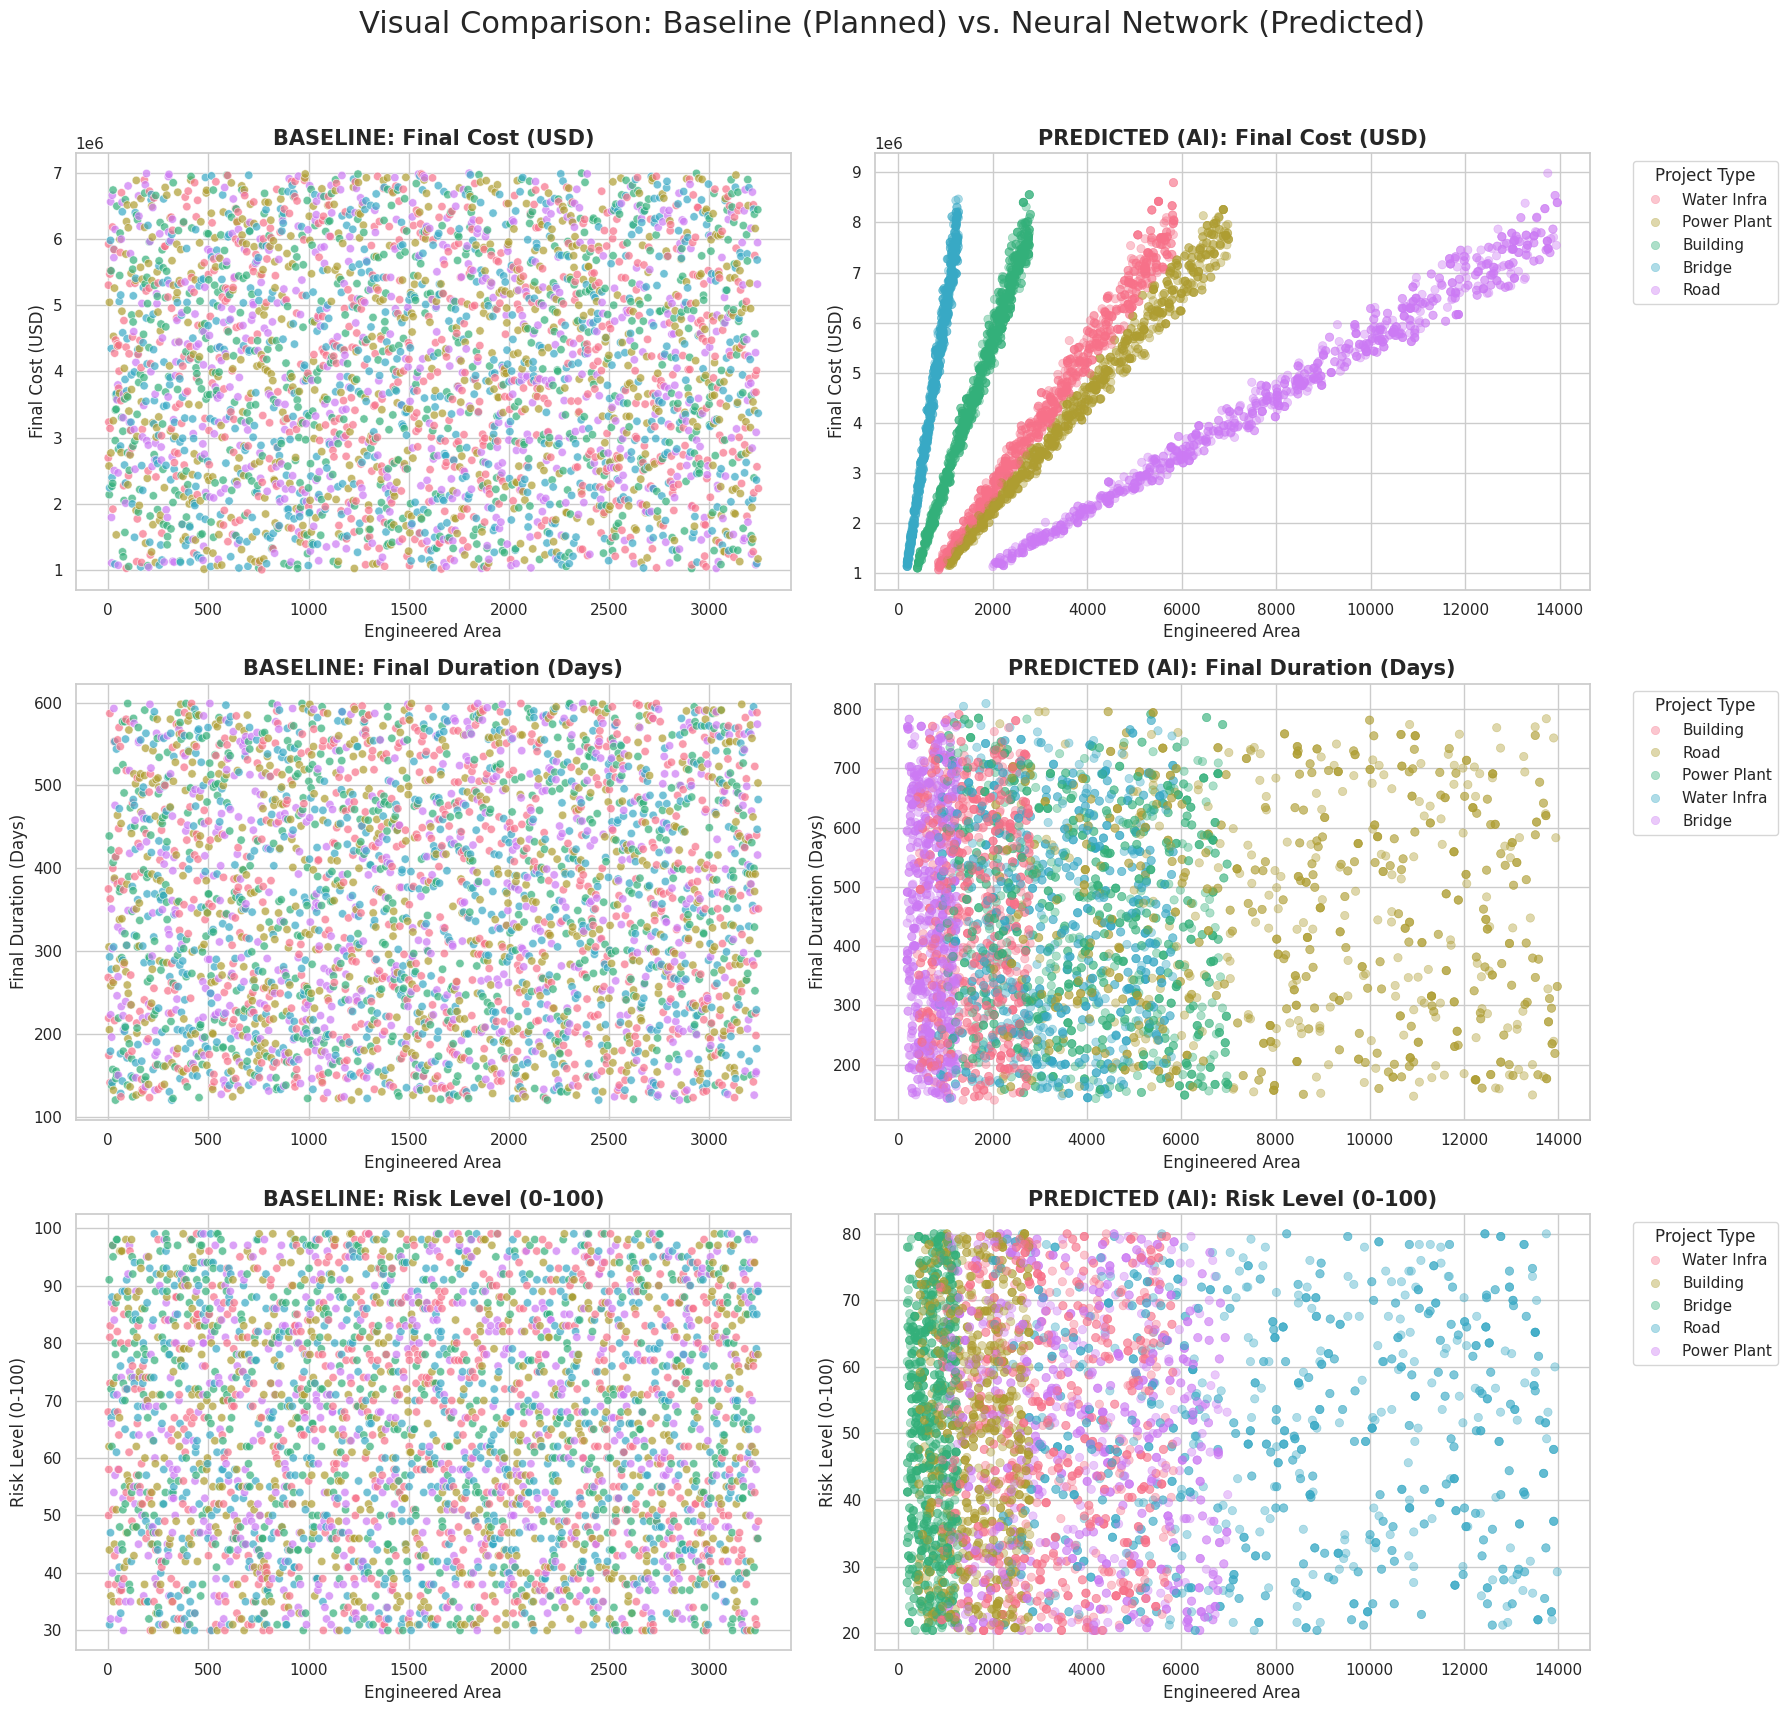

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure aesthetic style
sns.set_theme(style="whitegrid")
project_types = df_raw['Project_Type'].unique()
colors = sns.color_palette("husl", len(project_types))

# Create a 3x2 grid of subplots
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('Visual Comparison: Baseline (Planned) vs. Neural Network (Predicted)', fontsize=22)

# Define metrics and their corresponding columns
# format: (Original Column, Predicted Column, Label)
metrics = [
    ('Estimated_Cost_USD', 'Predicted_Final_Cost', 'Final Cost (USD)'),
    ('Time_Estimate_Days', 'Predicted_Final_Duration', 'Final Duration (Days)'),
    ('Risk_Assessment_Score', 'Predicted_Risk_Score', 'Risk Level (0-100)')
]

# Create a proxy for Predicted Risk if it doesn't exist as a column yet
if 'Predicted_Risk_Score' not in df_processed.columns:
    df_processed['Predicted_Risk_Score'] = (df_processed['Scope_Complexity_Numeric'] * 20) + (100 - df_processed['Resource_Allocation_Score']) * 0.4

# Loop through metrics to generate plots
for i, (orig_col, pred_col, label) in enumerate(metrics):

    # --- COLUMN 1: ORIGINAL DATA (BASELINE) ---
    sns.scatterplot(
        data=df_raw,
        x='Engineered_Area' if 'Engineered_Area' in df_raw.columns else df_raw.index,
        y=orig_col,
        hue='Project_Type',
        ax=axes[i, 0],
        palette=colors,
        alpha=0.7,
        edgecolor='w'
    )
    axes[i, 0].set_title(f'BASELINE: {label}', fontsize=15, fontweight='bold')
    axes[i, 0].set_ylabel(label)
    axes[i, 0].set_xlabel('Engineered Area')
    axes[i, 0].get_legend().remove() # Clean up left side

    # --- COLUMN 2: PROCESSED DATA (AI PREDICTIONS) ---
    # We use a sample for plotting to keep the visualization clear if data is too dense
    plot_data = df_processed.sample(min(5000, len(df_processed)))

    sns.scatterplot(
        data=plot_data,
        x='Engineered_Area',
        y=pred_col,
        hue='Project_Type',
        ax=axes[i, 1],
        palette=colors,
        alpha=0.4, # Transparency helps see density of the 21,000 generated points
        edgecolor=None
    )
    axes[i, 1].set_title(f'PREDICTED (AI): {label}', fontsize=15, fontweight='bold')
    axes[i, 1].set_ylabel(label)
    axes[i, 1].set_xlabel('Engineered Area')

    # Position the legend outside the plot
    axes[i, 1].legend(title='Project Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 4. Streamlit Web Application

In [ ]:
!pip install streamlit -q

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np
import random

# --- 1. APP CONFIGURATION ---
st.set_page_config(page_title="PHI - Project Health Suite", layout="wide")

# --- 2. ASSET LOADING ---
@st.cache_resource
def load_assets():
    try:
        model = joblib.load('phi_model.pkl')
        scaler_x = joblib.load('scaler_x.pkl')
        scaler_y = joblib.load('scaler_y.pkl')
        return model, scaler_x, scaler_y
    except Exception as e:
        st.error(f"Error loading AI assets: {e}. Please ensure 'phi_model.pkl', 'scaler_x.pkl', and 'scaler_y.pkl' are in the same directory.")
        return None, None, None

model, scaler_x, scaler_y = load_assets()

# --- 3. DATA CONSTANTS ---
STAGES = ['Site_Prep', 'Foundations', 'Structure', 'Systems', 'Finishing']
# Aligning with Project Types used in model training
UNIT_COSTS = {
    'Building': 2500, 'Road': 500, 'Bridge': 5500,
    'Water Infra': 2200, 'Power Plant': 7500
}

# Consistent with notebook's three_point_ranges
three_point_ranges = {
    'Building': {
        'Time': [(5,7,10), (10,12,15), (15,20,25), (20,25,30), (25,30,35)],
        'Cost': [(3,5,7), (10,13,15), (20,25,30), (20,28,35), (15,20,25)],
        'Risk': [(40,45,50), (80,85,90), (30,38,45), (50,58,65), (20,28,35)]
    },
    'Road': {
        'Time': [(10,15,20), (5,8,10), (40,45,50), (10,12,15), (5,7,10)],
        'Cost': [(15,20,25), (10,12,15), (30,40,45), (10,13,15), (5,7,10)],
        'Risk': [(20,25,30), (10,15,20), (40,45,50), (10,13,15), (5,7,10)]
    },
    'Bridge': {
        'Time': [(5,10,15), (20,25,30), (30,40,45), (10,12,15), (5,8,10)],
        'Cost': [(5,8,10), (25,30,35), (35,40,45), (10,13,15), (5,7,10)],
        'Risk': [(10,15,20), (40,50,60), (30,35,40), (10,15,20), (5,8,10)]
    },
    'Water Infra': {
        'Time': [(10,12,15), (20,22,25), (25,30,35), (15,18,20), (10,12,15)],
        'Cost': [(10,13,15), (15,20,25), (30,35,40), (15,18,20), (5,8,10)],
        'Risk': [(20,25,30), (20,25,30), (20,25,30), (10,13,15), (5,8,10)]
    },
    'Power Plant': {
        'Time': [(5,8,10), (15,18,20), (35,40,45), (20,22,25), (10,12,15)],
        'Cost': [(5,7,10), (10,15,20), (40,45,50), (20,23,25), (5,7,10)],
        'Risk': [(10,12,15), (20,25,30), (40,45,50), (15,18,20), (5,8,10)]
    }
}

def get_p90_monte_carlo_weights(p_type, metric_key, base_target=None):
    """
    Runs Monte Carlo to find P90 weights.
    Cost/Time = Sum Logic | Risk = Average Logic
    """
    data_map = three_point_ranges.get(p_type, three_point_ranges['Building'])
    tri_params = data_map.get(metric_key)
    iterations = 1000
    sims = []

    for _ in range(iterations):
        sample = [random.triangular(a, m, b) for (a, m, b) in tri_params]

        if metric_key == 'Risk':
            avg_sample = sum(sample) / len(sample)
            sims.append([s / (avg_sample / 1.0) for s in sample])
        else:
            total = sum(sample)
            sims.append([s / total for s in sample])

    p90_raw = np.percentile(np.array(sims), 90, axis=0)

    if metric_key == 'Risk':
        return p90_raw / (sum(p90_raw) / len(p90_raw))
    else:
        return p90_raw / sum(p90_raw)


# --- 4. SIDEBAR WEIGHTING ---
st.sidebar.header("⚖️ PHI Weighting Configuration")
w_cost_val = st.sidebar.slider("Cost Weight (%)", 0, 100, 40)
w_time_val = st.sidebar.slider("Time Weight (%)", 0, 100, 30)
w_risk_val = st.sidebar.slider("Risk Weight (%)", 0, 100, 30)

# Normalize weights to sum to 1.0
total_w = w_cost_val + w_time_val + w_risk_val
if total_w == 0:
    w_cost, w_time, w_risk = 0.33, 0.33, 0.34
else:
    w_cost = w_cost_val / total_w
    w_time = w_time_val / total_w
    w_risk = w_risk_val / total_w

# --- 5. MANDATORY & OPTIONAL INPUTS ---
st.title("🏗️ PHI - Project Health Index Suite")
st.markdown("---")

st.subheader("📋 Core Project Parameters")
col1, col2, col3 = st.columns(3)
with col1:
    p_type = st.selectbox("Project Type*", list(UNIT_COSTS.keys()))
with col2:
    area = st.number_input("Project Area (sqm)*", min_value=1.0, value=1200.0)
with col3:
    complexity = st.slider("Complexity (1-3)*", 1, 3, 2)

with st.expander("➕ Optional Initial Estimates"):
    opt_c1, opt_c2, opt_c3 = st.columns(3)
    # These target values are not directly used by the model but can be used for reference in the UI
    target_cost = opt_c1.number_input("Original Cost Estimate (USD)", value=0.0)
    target_days = opt_c2.number_input("Original Schedule Estimate (Days)", value=0.0)
    res_score = opt_c3.slider("Resource Confidence (%)", 0, 100, 85)
    historical_cost_deviation = 5.0 # Hardcoded for now, could be a slider

# --- 6. DYNAMIC MULTI-STAGE TRACKING ---
st.markdown("---")
st.subheader("🔄 Project Progress Tracking")
status = st.radio("Current Project Status:", ["No - Predictive Mode", "Yes - Tracking Mode"])

actual_stages_data = []

if status == "Yes - Tracking Mode":
    st.info("Select all completed stages and enter their specific actual data.")
    completed_stages = st.multiselect("Select Completed Stages:", STAGES)

    for stage in completed_stages:
        with st.container():
            st.markdown(f"**Data Entry for: {stage.replace('_', ' ')}**")
            sc1, sc2, sc3 = st.columns(3)
            a_cost = sc1.number_input(f"Actual Cost ({stage})", min_value=0.0, key=f"c_{stage}")
            a_days = sc2.number_input(f"Actual Days ({stage})", min_value=0.0, key=f"d_{stage}")
            a_risk = sc3.slider(f"Observed Risk ({stage})", 0, 100, 40, key=f"r_{stage}")

            actual_stages_data.append({
                "Stage": stage,
                "Cost": a_cost,
                "Days": a_days,
                "Risk": a_risk
            })
            st.markdown("---")

# --- 7. LOGIC & CALCULATIONS ---
if st.button("🚀 RUN PHI ANALYSIS"):
    if model is None or scaler_x is None or scaler_y is None:
        st.error("AI models not loaded. Cannot perform prediction. Please check the asset loading error above.")
    else:
        # 1. Baseline Reference
        base_cost = area * UNIT_COSTS.get(p_type, 1000) * (1 + (complexity-2)*0.2)
        base_days = (base_cost / 5000) * (1 + (complexity-2)*0.1)
        base_risk_for_stages = 50.0 + (complexity * 10) # Used for stage risk distribution

        engineered_area = round(base_cost / UNIT_COSTS.get(p_type, 1000.0), 2)

        # 2. P90 Distributions (Applying Weighting)
        c_w = get_p90_monte_carlo_weights(p_type, 'Cost')
        t_w = get_p90_monte_carlo_weights(p_type, 'Time')
        r_w = get_p90_monte_carlo_weights(p_type, 'Risk')

        # Constructing planned_stages for model input, matching the features order from model training
        planned_stages_for_model = []
        for i in range(len(STAGES)):
            planned_stages_for_model.append(base_cost * c_w[i]) # Cost for stage i
            planned_stages_for_model.append(base_days * t_w[i]) # Days for stage i
            planned_stages_for_model.append(base_risk_for_stages * r_w[i]) # Risk for stage i

        # Project Type dummy variables (matching model training order)
        project_types_for_dummies = ['Bridge', 'Building', 'Power Plant', 'Road', 'Water Infra'] # Must match training order
        type_dummies = [1.0 if t == p_type else 0.0 for t in project_types_for_dummies]

        # Combine all features for model input (order is critical!)
        input_data = [
            engineered_area,
            float(complexity),
            float(res_score),
            base_cost, # Estimated_Cost_USD
            historical_cost_deviation, # Historical_Cost_Deviation_%
            base_days # Time_Estimate_Days
        ] + planned_stages_for_model + type_dummies

        # Convert to numpy array and reshape for single prediction
        input_array = np.array(input_data).reshape(1, -1)

        # Scale inputs
        input_scaled = scaler_x.transform(input_array)

        # Make prediction
        preds_scaled = model.predict(input_scaled)

        # Inverse transform to get original scale predictions
        preds = scaler_y.inverse_transform(preds_scaled)[0]

        # The model predicts: [Predicted_Final_Duration, Predicted_Delay_Days, Predicted_Final_Cost]
        predicted_final_duration = preds[0]
        predicted_delay_days = preds[1]
        predicted_final_cost = preds[2]

        # Default AI predicted values from model
        ai_final_cost = predicted_final_cost
        ai_final_days = predicted_final_duration

        if status == "Yes - Tracking Mode" and actual_stages_data:
            total_actual_cost = sum(i['Cost'] for i in actual_stages_data)
            total_actual_days = sum(i['Days'] for i in actual_stages_data)
            avg_actual_risk = sum(i['Risk'] for i in actual_stages_data) / len(actual_stages_data)

            # Calculate Progress based on number of stages completed
            last_stage_name = actual_stages_data[-1]['Stage']
            last_idx = STAGES.index(last_stage_name)
            progress_pct = (last_idx + 1) / len(STAGES)

            # EAC Logic: Update AI prediction based on actuals
            # This is a simplified EAC (Estimate at Completion) formula
            final_eac_cost = total_actual_cost + (ai_final_cost * (1 - progress_pct)) if progress_pct < 1 else total_actual_cost
            final_eac_days = total_actual_days + (ai_final_days * (1 - progress_pct)) if progress_pct < 1 else total_actual_days

            # Performance KPIs
            # Assuming base_cost and base_days are the planned total for the project
            ev = base_cost * progress_pct
            cpi = ev / total_actual_cost if total_actual_cost > 0 else 1.0
            spi = (base_days * progress_pct) / total_actual_days if total_actual_days > 0 else 1.0
            s_risk = avg_actual_risk
        else:
            # Predictive Mode Defaults based on AI model output
            final_eac_cost = ai_final_cost
            final_eac_days = ai_final_days
            # For predictive mode, risk is just the base risk from parameters (or an average from the model prediction if available)
            # Since the model predicts overall final risk, we can use an average of stage risks or a simpler proxy
            s_risk = base_risk_for_stages # Using the base risk derived from complexity

        # Final PHI Formula
        # Ensure KPI values are within reasonable bounds for PHI calculation
        norm_cpi = np.clip(cpi, 0, 1.2)
        norm_spi = np.clip(spi, 0, 1.2)
        norm_risk = (100 - np.clip(s_risk, 0, 100)) / 100 # Invert risk score for "health" metric

        phi_index = (norm_cpi * 85 * w_cost) + (norm_spi * 85 * w_time) + (norm_risk * 100 * w_risk)

        # --- 8. DASHBOARD DISPLAY ---
        st.divider()

        # Health Card
        st.markdown(f"""
            <div style="background-color: #ffffff; border: 2px solid #b71c1c; padding: 25px; border-radius: 15px; text-align: center; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
                <h1 style="color: #b71c1c; font-size: 50px; margin: 0;">{phi_index:.1f}%</h1>
                <p style="color: #666; font-weight: bold; text-transform: uppercase; letter-spacing: 1px;">Overall Project Health Index</p>
            </div>
        """, unsafe_allow_html=True)

        st.write("###")

        m1, m2, m3 = st.columns(3)
        m1.metric("CPI (Cost Index)", f"{cpi:.2f}", delta=f"{cpi-1:.2f}")
        m2.metric("SPI (Schedule Index)", f"{spi:.2f}", delta=f"{spi-1:.2f}")
        m3.metric("Aggregated Risk", f"{s_risk:.0f}/100", delta_color="inverse")

        # Forecast Section
        st.subheader("📋 AI Forecast per Stage")
        breakdown = []
        # Distribute the AI-predicted total cost/days to stages using the same weights
        for i, s in enumerate(STAGES):
            breakdown.append({
                "Stage": s.replace('_', ' '),
                "Predicted Cost": f"${predicted_final_cost * c_w[i]:,.2f}",
                "Predicted Duration (Days)": f"{predicted_final_duration * t_w[i]:,.1f}",
                "AI Risk Prob.": f"{base_risk_for_stages * r_w[i]:.1f}%" # Using distributed base risk
            })
        st.table(pd.DataFrame(breakdown))

        # EAC Results
        res_col1, res_col2 = st.columns(2)
        res_col1.success(f"**Final Predicted Cost (EAC):** ${final_eac_cost:,.2f}")
        res_col2.info(f"**Final Predicted Duration:** {final_eac_days:,.1f} Days")

Overwriting app.py


In [ ]:
!npm install -g localtunnel
!streamlit run app.py & npx localtunnel --port 8501


⠙⠹⠸⠼⠴⠦⠧
changed 22 packages in 1s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧⠙⠹⠸

⠼⠴⠦⠧⠇your url is: https://famous-worlds-worry.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.199.172.218:8501

  Stopping...
^C


In [ ]:
pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

# Terminate any previous ngrok tunnels
ngrok.kill()

# Authenticate ngrok. You might be prompted to get an authtoken from ngrok.com.
# If you've already authenticated in a previous session, this might not be strictly necessary.
# ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN") # Uncomment and replace if you have an authtoken

# Start Streamlit in the background
!streamlit run app.py &

# Create a public URL for Streamlit
public_url = ngrok.connect(8501)
print(f"Streamlit App URL: {public_url}")




  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://104.199.172.218:8501

  Stopping...
  Stopping...
Exception ignored in: <module 'threading' from '/usr/lib/python3.12/threading.py'>
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1594, in _shutdown
    atexit_call()
  File "/usr/lib/python3.12/concurrent/futures/thread.py", line 31, in _python_exit
    t.join()
  File "/usr/lib/python3.12/threading.py", line 1149, in join
    self._wait_for_tstate_lock()
  File "/usr/lib/python3.12/threading.py", line 1169, in _wait_for_tstate_lock
    if lock.acquire(block, timeout):
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/bootstrap.py", line 43, in signal_handler
    server.stop()
  File "/usr/local/lib/python3.12/dist-packages/streamlit/web/server/server.py", line 550, in stop
    self._runtime.stop()
 

ERROR:pyngrok.process.ngrok:t=2026-04-18T21:03:17+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-18T21:03:17+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-18T21:03:17+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.